<h1 style="color:blue;text-size:38px;border:3px solid black;background-color:white;text-align:center">Imports</h1>

In [ ]:

# Imports and Configurations like seed for same random result each time


import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Paths
BASE_DIR = "data"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

# Image config
IMG_SIZE = (224, 224)   
BATCH_SIZE = 32
SEED = 42

print("Train path:", TRAIN_DIR)
print("Val path  :", VAL_DIR)
print("Test path :", TEST_DIR)


<h1 style="color:blue;text-size:38px;border:3px solid black;background-color:white;text-align:center">Loading the datasets</h1>

In [ ]:

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",     
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
        subset="training",
     validation_split=0.15,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
      subset="validation",
          validation_split=0.15,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)


<h1 style="color:blue;text-size:38px;border:3px solid black;background-color:white;text-align:center">Preprocessing</h1>

In [ ]:

# Data Augmentation model Layer 

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name="data_augmentation")


In [ ]:

# Preprocessing and data Augmentation

normalization_layer = tf.keras.layers.Rescaling(1./255)

# Training: augmentation + normalization
train_ds = train_ds.map(
    lambda x, y: (normalization_layer(data_augmentation(x, training=True)), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Validation & Test: normalization only
val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Prefetch for performance
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.prefetch(tf.data.AUTOTUNE)


<h1 style="color:blue;text-size:38px;border:3px solid black;background-color:white;text-align:center">Building the CNN</h1>

In [ ]:
def build_cnn(input_shape=(224, 224, 3)):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, 3, activation="relu", input_shape=input_shape),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(128, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    return model

model = build_cnn()
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 54, 54, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 26, 26, 128)      0

<h1 style="color:blue;text-size:38px;border:3px solid black;background-color:white;text-align:center">Compiling the CNN</h1>

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


<h1 style="color:blue;text-size:38px;border:3px solid black;background-color:white;text-align:center">Training the CNN</h1>

In [ ]:

# EarlyStopping + ReduceLROnPlateau for regurlization
import pickle

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",       # most stable metric
        patience=6,               # wait before stopping 6 epochs
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,               # reduce LR by half
        patience=3,               # wait before reducing 3 epochs
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "pneumonia_best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]


history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)


# Save final model (best weights already restored)


model.save("pneumonia_final_model.keras")


# Save training history


with open("pneumonia_training_history.pkl", "wb") as f:
    pickle.dump(history.history, f)

print(" Training complete")
print(" Model saved as pneumonia_final_model.keras")
print(" History saved as pneumonia_training_history.pkl")



Epoch 1/20
139/139 [==============================] - ETA: 0s - loss: 0.4592 - accuracy: 0.7876
Epoch 1: val_loss improved from inf to 0.33625, saving model to pneumonia_best_model.keras
139/139 [==============================] - 75s 528ms/step - loss: 0.4592 - accuracy: 0.7876 - val_loss: 0.3362 - val_accuracy: 0.8159 - lr: 1.0000e-04
Epoch 2/20
139/139 [==============================] - ETA: 0s - loss: 0.2433 - accuracy: 0.9044
Epoch 2: val_loss improved from 0.33625 to 0.09630, saving model to pneumonia_best_model.keras
139/139 [==============================] - 77s 546ms/step - loss: 0.2433 - accuracy: 0.9044 - val_loss: 0.0963 - val_accuracy: 0.9565 - lr: 1.0000e-04
Epoch 3/20
139/139 [==============================] - ETA: 0s - loss: 0.2020 - accuracy: 0.9226
Epoch 3: val_loss did not improve from 0.09630
139/139 [==============================] - 77s 545ms/step - loss: 0.2020 - accuracy: 0.9226 - val_loss: 0.1000 - val_accuracy: 0.9527 - lr: 1.0000e-04
Epoch 4/20
139/139 [======

<h1 style="color:blue;text-size:38px;border:3px solid black;background-color:white;text-align:center">Loading the model after training</h1>

In [5]:
import tensorflow as tf

model = tf.keras.models.load_model("pneumonia_final_model.keras")
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 54, 54, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 26, 26, 128)      0

<h1 style="color:blue;text-size:38px;border:3px solid black;background-color:white;text-align:center">Loading the model training history after training</h1>

In [1]:
import pickle
import matplotlib.pyplot as plt

with open("pneumonia_training_history.pkl", "rb") as f:
    history = pickle.load(f)


<h1 style="color:blue;text-size:38px;border:3px solid black;background-color:white;text-align:center">Evaluating the model</h1>

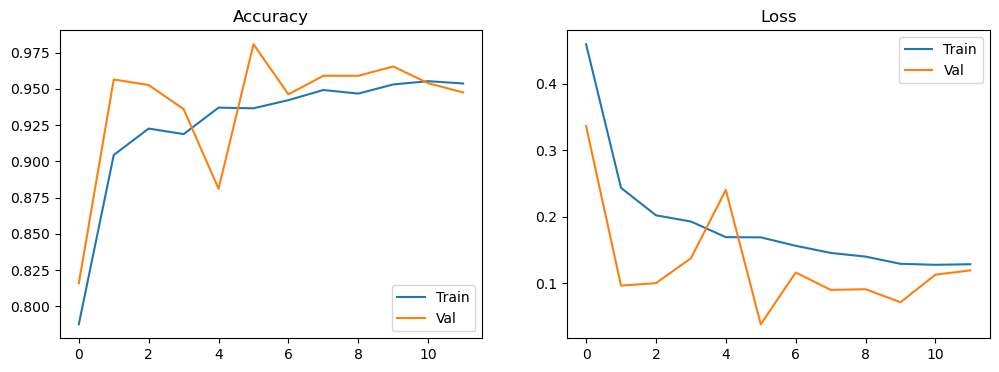

In [3]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history["accuracy"], label="Train")
plt.plot(history["val_accuracy"], label="Val")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history["loss"], label="Train")
plt.plot(history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()

plt.show()


In [10]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


20/20 [==============================] - 4s 167ms/step - loss: 61.5731 - accuracy: 0.8718
Test Loss: 61.5731
Test Accuracy: 0.8718


In [12]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)[0][0]
    label = "PNEUMONIA" if pred > 0.5 else "NORMAL"

    print(f"Prediction: {label}")
    print(f"Confidence: {pred:.3f}")

# Example
predict_image("data/test/PNEUMONIA/person1_virus_6.jpeg")


1/1 [==============================] - 0s 19ms/step
Prediction: PNEUMONIA
Confidence: 1.000


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# 1) Collect predictions on the test set
y_true, y_pred = [], []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0).ravel()   # probabilities for class=1 (PNEUMONIA)
    preds = (probs >= 0.5).astype(int)                 # threshold at 0.5
    y_true.extend(labels.numpy().astype(int))
    y_pred.extend(preds.astype(int))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

class_names = ["NORMAL", "PNEUMONIA"]

# 2) Classification report as dict -> DataFrame (NO errors)
report_dict = classification_report(
    y_true, y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).T  # rows: classes + avg rows
# keep only useful columns and nicer rounding
cols_to_show = ["precision", "recall", "f1-score", "support"]
report_df = report_df[cols_to_show].copy()
report_df[["precision", "recall", "f1-score"]] = report_df[["precision", "recall", "f1-score"]].round(3)
report_df["support"] = report_df["support"].astype(int)

print("=== Classification Report (table) ===")
display(report_df)

=== Classification Report (table) ===


,precision,recall,f1-score,support
NORMAL,0.923,0.718,0.808,234
PNEUMONIA,0.851,0.964,0.904,390
accuracy,0.872,0.872,0.872,0
macro avg,0.887,0.841,0.856,624
weighted avg,0.878,0.872,0.868,624


{'NORMAL': {'precision': 0.9230769230769231,
  'recall': 0.717948717948718,
  'f1-score': 0.8076923076923078,
  'support': 234.0},
 'PNEUMONIA': {'precision': 0.8506787330316742,
  'recall': 0.9641025641025641,
  'f1-score': 0.9038461538461539,
  'support': 390.0},
 'accuracy': 0.8717948717948718,
 'macro avg': {'precision': 0.8868778280542986,
  'recall': 0.841025641025641,
  'f1-score': 0.8557692307692308,
  'support': 624.0},
 'weighted avg': {'precision': 0.8778280542986425,
  'recall': 0.8717948717948718,
  'f1-score': 0.8677884615384616,
  'support': 624.0}}

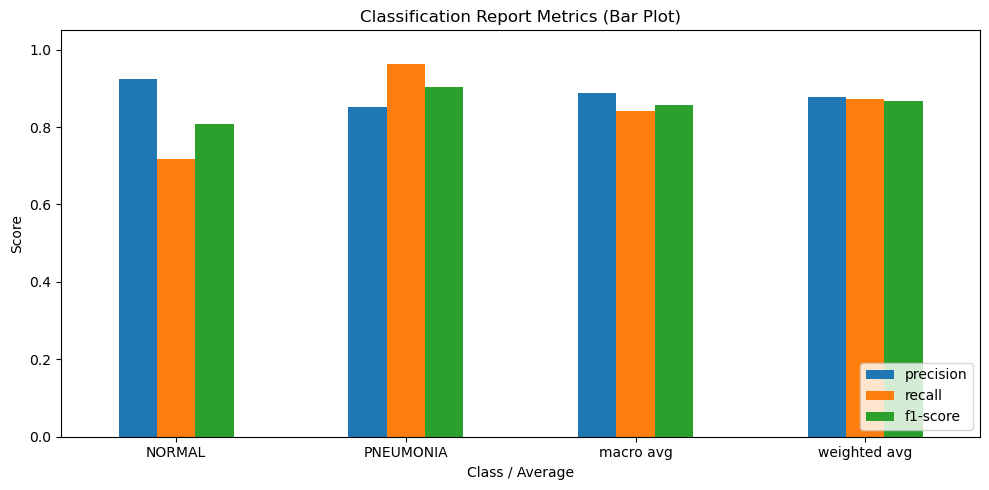

In [21]:
# 4) Bar plots for precision/recall/f1 (per class + macro/weighted)
rows_for_plot = ["NORMAL", "PNEUMONIA", "macro avg", "weighted avg"]
plot_df = report_df.loc[rows_for_plot, ["precision", "recall", "f1-score"]]

ax = plot_df.plot(kind="bar", figsize=(10, 5))
plt.title("Classification Report Metrics (Bar Plot)")
plt.xlabel("Class / Average")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

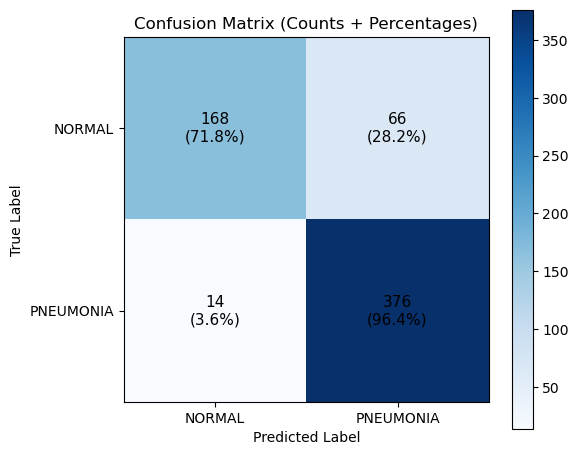

In [ ]:

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Convert to percentages (row-wise)
cm_percent = cm.astype("float") / cm.sum(axis=1, keepdims=True) * 100

# Plot
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (Counts + Percentages)")
plt.colorbar()

class_names = ["NORMAL", "PNEUMONIA"]
plt.xticks([0,1], class_names)
plt.yticks([0,1], class_names)

# Add text (count + percentage)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i,
            f"{cm[i, j]}\n({cm_percent[i, j]:.1f}%)",
            ha="center",
            va="center",
            color="black",
            fontsize=11
        )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()
